<a href="https://colab.research.google.com/github/kalyankargouri/Deep-Learning/blob/main/DLexper5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
x_train = x_train[:10000]
y_train = y_train[:10000]

x_test = x_test[:2000]
y_test = y_test[:2000]

In [4]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# One-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# Resize (lightweight)
x_train = tf.image.resize(x_train, (96, 96))
x_test = tf.image.resize(x_test, (96, 96))

In [5]:
base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(96,96,3))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
for layer in base_model.layers:
    layer.trainable = False

In [11]:
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(128, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

In [14]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history1 = model.fit(x_train, y_train,
                     epochs=3,
                     validation_data=(x_test, y_test))

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 95s 285ms/step - accuracy: 0.8405 - loss: 0.4603 - val_accuracy: 0.7785 - val_loss: 0.6673
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 281ms/step - accuracy: 0.8717 - loss: 0.3748 - val_accuracy: 0.7840 - val_loss: 0.6679
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 296ms/step - accuracy: 0.8916 - loss: 0.3121 - val_accuracy: 0.7635 - val_loss: 0.7527


In [15]:
for layer in base_model.layers[-10:]:
    layer.trainable = True

In [16]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [17]:
history2 = model.fit(x_train, y_train,
                     epochs=3,
                     validation_data=(x_test, y_test))

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 126s 379ms/step - accuracy: 0.7070 - loss: 1.0292 - val_accuracy: 0.7710 - val_loss: 0.8430
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 117s 375ms/step - accuracy: 0.7912 - loss: 0.6438 - val_accuracy: 0.7670 - val_loss: 0.8380
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 141s 372ms/step - accuracy: 0.8162 - loss: 0.5430 - val_accuracy: 0.7775 - val_loss: 0.8090


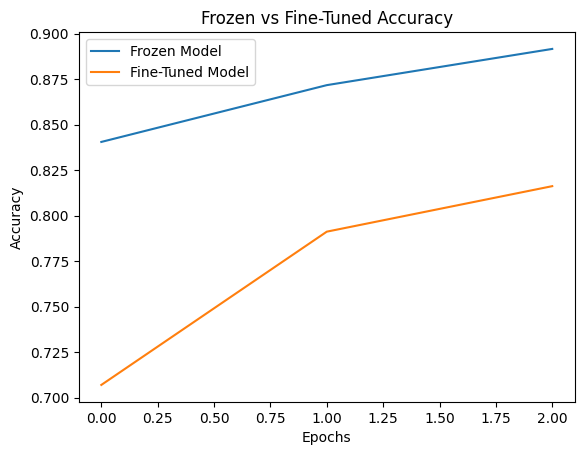

In [18]:
plt.plot(history1.history['accuracy'], label='Frozen Model')
plt.plot(history2.history['accuracy'], label='Fine-Tuned Model')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Frozen vs Fine-Tuned Accuracy')
plt.legend()
plt.show()

In [19]:
pred = model.predict(x_test)
print("Predicted class:", pred[0].argmax())

63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 253ms/step
Predicted class: 3
